# Бенчмарки cache policies и анализ hit-rate

Этот notebook запускает проектный benchmark, сравнивает online-стратегии с offline-оптимумом Belady и строит графики для практического выбора кэша.

Главная метрика — **hit-rate, % от Belady**: `100 × hits(strategy) / hits(Belady)` на том же trace и с тем же суммарным resident capacity. Значение 100% означает совпадение с offline-оптимумом по числу hits. Для trace без единого возможного hit метрика по принятому в benchmark соглашению равна 100%.

> Рейтинг ниже использует макро-среднее: каждый trace имеет одинаковый вес. Синтетические workloads полезны для сравнения алгоритмов, но окончательный выбор лучше подтвердить репрезентативными production traces.

In [1]:
from __future__ import annotations

import csv
import os
import re
import statistics
import subprocess
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'scripts' / 'benchmark.py').is_file():
    raise RuntimeError('Запустите notebook из корня проекта CacheResearch')

RESULTS_CSV = PROJECT_ROOT / 'results' / 'benchmark.csv'
PATTERN_ORDER = ['loop', 'scan', 'uniform', 'normal', 'hotset', 'hot_scan', 'phase_change', 'zipf']
COLORS = list(plt.get_cmap('tab10').colors)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print(f'Project root: {PROJECT_ROOT}')

Project root: /home/lenoz/CLionProjects/CacheResearch


## 1. Запуск benchmark

При `RUN_BENCHMARK = True` ячейка запускает все пары generated config × workload и Belady baseline. Release-бинарник собирается автоматически, если отсутствует. Входные данные генерируются автоматически, если отсутствуют; принудительную регенерацию можно включить отдельно.

Полный штатный набор сейчас содержит 125 трёхуровневых конфигураций и 48 traces. Результат сохраняется в `results/benchmark.csv`.

In [2]:
RUN_BENCHMARK = True
REBUILD_RELEASE = False
REGENERATE_INPUTS = False
JOBS = min(8, os.cpu_count() or 1)
TIMEOUT_SECONDS = 30

executable = PROJECT_ROOT / 'build' / 'release' / 'cache_sim'
configs_dir = PROJECT_ROOT / 'configs' / 'generated' / '3-level'
workloads_dir = PROJECT_ROOT / 'workloads' / 'generated'

def run(command: list[str]) -> None:
    print('$', ' '.join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

if REBUILD_RELEASE or not executable.is_file():
    run(['cmake', '--preset', 'release'])
    run(['cmake', '--build', '--preset', 'release', '--parallel'])

inputs_missing = (
    not any(configs_dir.glob('*.conf'))
    or not any(workloads_dir.rglob('*.trace'))
)
if REGENERATE_INPUTS or inputs_missing:
    run(['python3', 'scripts/generate_configs.py', '--levels', '3', '--clean'])
    run(['python3', 'scripts/generate_workloads.py', '--levels', '3', '--clean'])

if RUN_BENCHMARK or not RESULTS_CSV.is_file():
    run([
        'python3', 'scripts/benchmark.py',
        '--executable', str(executable),
        '--configs', str(configs_dir),
        '--workloads', str(workloads_dir),
        '--output', str(RESULTS_CSV),
        '--jobs', str(JOBS),
        '--timeout', str(TIMEOUT_SECONDS),
    ])
else:
    print(f'Используется существующий файл: {RESULTS_CSV}')

$ python3 scripts/benchmark.py --executable /home/lenoz/CLionProjects/CacheResearch/build/release/cache_sim --configs /home/lenoz/CLionProjects/CacheResearch/configs/generated/3-level --workloads /home/lenoz/CLionProjects/CacheResearch/workloads/generated --output /home/lenoz/CLionProjects/CacheResearch/results/benchmark.csv --jobs 8 --timeout 30
completed 300/6000 runs
completed 600/6000 runs
completed 900/6000 runs
completed 1200/6000 runs
completed 1500/6000 runs
completed 1800/6000 runs
completed 2100/6000 runs
completed 2400/6000 runs
completed 2700/6000 runs
completed 3000/6000 runs
completed 3300/6000 runs
completed 3600/6000 runs
completed 3900/6000 runs
completed 4200/6000 runs
completed 4500/6000 runs
completed 4800/6000 runs
completed 5100/6000 runs
completed 5400/6000 runs
completed 5700/6000 runs
completed 6000/6000 runs
wrote 6000 rows to /home/lenoz/CLionProjects/CacheResearch/results/benchmark.csv
wrote 48 best configurations to /home/lenoz/CLionProjects/CacheResearch/r

## 2. Загрузка и проверка данных

In [3]:
INTEGER_FIELDS = {
    'cache_size_per_level', 'total_capacity', 'requests', 'levels',
    'hits', 'misses', 'ideal_hits',
}
FLOAT_FIELDS = {'hit_rate', 'ideal_hit_rate', 'percent_of_ideal', 'seconds'}

def load_results(path: Path) -> list[dict[str, object]]:
    with path.open(encoding='utf-8', newline='') as source:
        raw_rows = list(csv.DictReader(source))

    rows: list[dict[str, object]] = []
    for raw in raw_rows:
        row: dict[str, object] = dict(raw)
        for field in INTEGER_FIELDS:
            row[field] = int(raw[field]) if raw.get(field) else None
        for field in FLOAT_FIELDS:
            row[field] = float(raw[field]) if raw.get(field) else None
        rows.append(row)
    return rows

all_rows = load_results(RESULTS_CSV)
failed_rows = [row for row in all_rows if row['status'] != 'ok']
if failed_rows:
    examples = '; '.join(f"{r['workload']}: {r['error']}" for r in failed_rows[:3])
    raise RuntimeError(f'{len(failed_rows)} benchmark runs failed. Examples: {examples}')

rows = [row for row in all_rows if row['status'] == 'ok']
assert rows and all(row['percent_of_ideal'] is not None for row in rows), 'Нужен benchmark с Belady baseline'
workloads = sorted({str(row['workload']) for row in rows})
configs = sorted({str(row['policies']) for row in rows})
patterns = [name for name in PATTERN_ORDER if any(row['pattern'] == name for row in rows)]
patterns += sorted({str(row['pattern']) for row in rows} - set(patterns))

print(f'Строк: {len(rows):,}')
print(f'Конфигураций: {len(configs)}')
print(f'Trace-тестов: {len(workloads)}')
print(f'Паттернов: {len(patterns)} — {", ".join(patterns)}')

Строк: 6,000
Конфигураций: 125
Trace-тестов: 48
Паттернов: 8 — loop, scan, uniform, normal, hotset, hot_scan, phase_change, zipf


In [4]:
by_config: dict[str, list[dict[str, object]]] = defaultdict(list)
for row in rows:
    by_config[str(row['policies'])].append(row)

config_summary = []
for policies, group in by_config.items():
    ideal_percent = [float(row['percent_of_ideal']) for row in group]
    config_summary.append({
        'policies': policies,
        'mean_percent_of_ideal': statistics.fmean(ideal_percent),
        'median_percent_of_ideal': statistics.median(ideal_percent),
        'min_percent_of_ideal': min(ideal_percent),
        'mean_hit_rate_percent': statistics.fmean(float(row['hit_rate']) for row in group) * 100,
        'throughput_req_s': sum(int(row['requests']) for row in group) / sum(float(row['seconds']) for row in group),
        'runs': len(group),
    })

config_summary.sort(key=lambda item: (-item['mean_percent_of_ideal'], item['policies']))
top5 = [str(item['policies']) for item in config_summary[:5]]

print('Топ-5 по среднему hit-rate, % от Belady')
print(f"{'#':>2}  {'политики':<22} {'mean':>8} {'median':>8} {'min':>8}")
for rank, item in enumerate(config_summary[:5], 1):
    print(
        f"{rank:>2}  {item['policies']:<22} "
        f"{item['mean_percent_of_ideal']:>7.2f}% "
        f"{item['median_percent_of_ideal']:>7.2f}% "
        f"{item['min_percent_of_ideal']:>7.2f}%"
    )

Топ-5 по среднему hit-rate, % от Belady
 #  политики                   mean   median      min
 1  LIRS>LIRS>LIRS           70.36%   89.15%   24.95%
 2  LFU>LIRS>LIRS            67.01%   73.57%   24.69%
 3  2Q>LIRS>LIRS             66.11%   71.61%   24.69%
 4  LIRS>ARC>LIRS            66.06%   72.89%   24.43%
 5  LIRS>LFU>LIRS            66.06%   72.89%   24.43%


## 3. Топ-5 стратегий на каждом trace

Стратегии отбираются по среднему проценту от Belady на всех тестах. По горизонтали — отдельные traces, сгруппированные по паттерну; цвет закреплён за конфигурацией. Пунктир 100% — offline optimum.

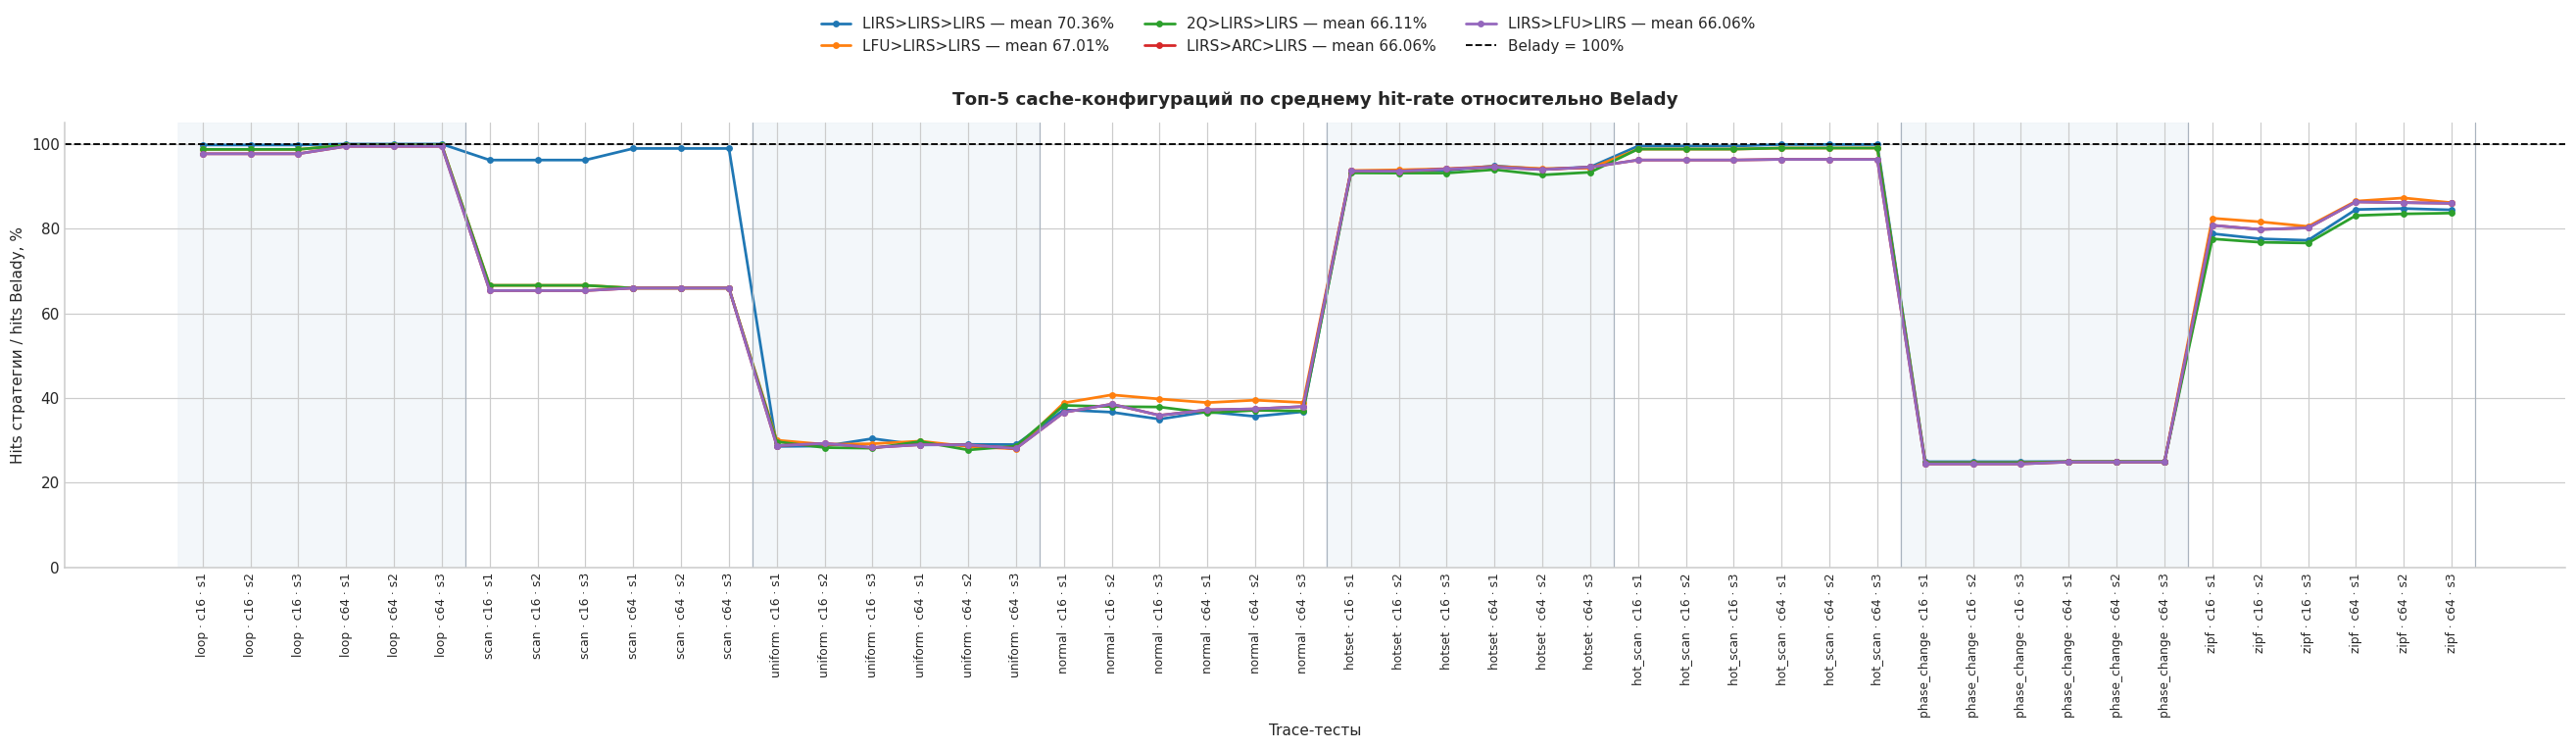

In [5]:
pattern_rank = {pattern: index for index, pattern in enumerate(patterns)}

def workload_parts(row: dict[str, object]) -> tuple[int, int]:
    match = re.search(r'_c(\d+)_n\d+_s(-?\d+)\.trace$', str(row['workload']))
    return (int(match.group(1)), int(match.group(2))) if match else (int(row['cache_size_per_level']), 0)

representative_rows = {}
for row in rows:
    representative_rows.setdefault(str(row['workload']), row)

ordered_workloads = sorted(
    workloads,
    key=lambda name: (
        pattern_rank.get(str(representative_rows[name]['pattern']), len(patterns)),
        *workload_parts(representative_rows[name]),
        name,
    ),
)
labels = []
for name in ordered_workloads:
    row = representative_rows[name]
    capacity, seed = workload_parts(row)
    labels.append(f"{row['pattern']} · c{capacity} · s{seed}")

score = {(str(row['policies']), str(row['workload'])): float(row['percent_of_ideal']) for row in rows}
mean_score = {str(item['policies']): float(item['mean_percent_of_ideal']) for item in config_summary}

fig, ax = plt.subplots(figsize=(24, 7))
x = list(range(len(ordered_workloads)))
for index, policies in enumerate(top5):
    y = [score[(policies, workload)] for workload in ordered_workloads]
    ax.plot(
        x, y, marker='o', markersize=3.5, linewidth=1.8, color=COLORS[index],
        label=f'{policies} — mean {mean_score[policies]:.2f}%',
    )

previous_pattern = None
block_start = 0
for position, workload in enumerate(ordered_workloads + [None]):
    pattern = None if workload is None else str(representative_rows[workload]['pattern'])
    if previous_pattern is None:
        previous_pattern = pattern
    elif pattern != previous_pattern:
        if pattern_rank.get(previous_pattern, 0) % 2 == 0:
            ax.axvspan(block_start - 0.5, position - 0.5, color='#eef3f8', alpha=0.65, zorder=0)
        ax.axvline(position - 0.5, color='#aab4bf', linewidth=0.8)
        block_start = position
        previous_pattern = pattern

ax.axhline(100, color='black', linestyle='--', linewidth=1.2, label='Belady = 100%')
ax.set_xticks(x, labels, rotation=90, fontsize=8)
ax.set_ylabel('Hits стратегии / hits Belady, %')
ax.set_xlabel('Trace-тесты')
ax.set_ylim(0, 105)
ax.set_title('Топ-5 cache-конфигураций по среднему hit-rate относительно Belady', pad=12)
handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(handles, legend_labels, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 0.995), frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

## 4. Какой кэш подходит под тип нагрузки

Среднее скрывает специализацию алгоритмов. Heatmap показывает средний процент от Belady отдельно для каждого паттерна. Чем светлее и больше число, тем ближе стратегия к идеалу.

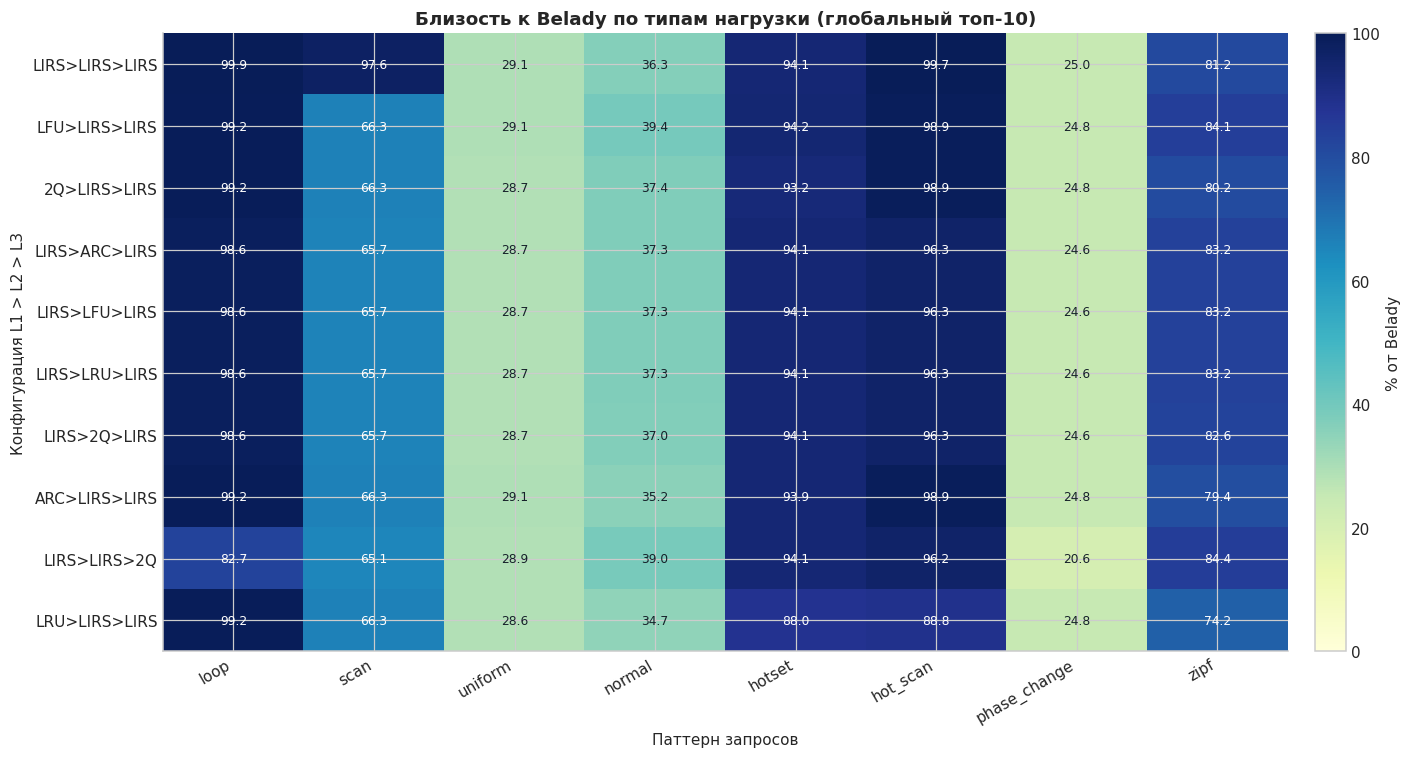

In [6]:
TOP_N_HEATMAP = 10
heatmap_configs = [str(item['policies']) for item in config_summary[:TOP_N_HEATMAP]]
pattern_scores: dict[tuple[str, str], list[float]] = defaultdict(list)
for row in rows:
    pattern_scores[(str(row['policies']), str(row['pattern']))].append(float(row['percent_of_ideal']))

matrix = [
    [statistics.fmean(pattern_scores[(policies, pattern)]) for pattern in patterns]
    for policies in heatmap_configs
]

fig, ax = plt.subplots(figsize=(14, 7))
image = ax.imshow(matrix, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
ax.set_xticks(range(len(patterns)), patterns, rotation=30, ha='right')
ax.set_yticks(range(len(heatmap_configs)), heatmap_configs)
for row_index, values in enumerate(matrix):
    for column_index, value in enumerate(values):
        ax.text(
            column_index, row_index, f'{value:.1f}',
            ha='center', va='center', fontsize=8,
            color='white' if value > 58 else '#16212a',
        )
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label('% от Belady')
ax.set_title('Близость к Belady по типам нагрузки (глобальный топ-10)')
ax.set_xlabel('Паттерн запросов')
ax.set_ylabel('Конфигурация L1 > L2 > L3')
fig.tight_layout()
plt.show()

In [7]:
print('Лучшая конфигурация для каждого паттерна')
print(f"{'pattern':<16} {'policies':<22} {'% Belady':>10} {'hit-rate':>10}")
for pattern in patterns:
    candidates = []
    for policies in configs:
        group = [row for row in by_config[policies] if row['pattern'] == pattern]
        candidates.append((
            statistics.fmean(float(row['percent_of_ideal']) for row in group),
            statistics.fmean(float(row['hit_rate']) for row in group) * 100,
            policies,
        ))
    ideal_percent, hit_rate_percent, policies = max(candidates, key=lambda item: (item[0], item[1], item[2]))
    print(f'{pattern:<16} {policies:<22} {ideal_percent:>9.2f}% {hit_rate_percent:>9.2f}%')

Лучшая конфигурация для каждого паттерна
pattern          policies                 % Belady   hit-rate
loop             LIRS>LIRS>LIRS             99.89%     97.39%
scan             LIRS>LIRS>LIRS             97.58%     11.52%
uniform          ARC>LIRS>2Q                29.41%     12.62%
normal           LFU>LIRS>2Q                41.22%     22.14%
hotset           ARC>LRU>LRU                94.22%     81.43%
hot_scan         LIRS>LIRS>LIRS             99.70%     54.04%
phase_change     LIRS>LIRS>LIRS             24.97%     23.45%
zipf             LFU>2Q>2Q                  86.01%     70.03%


## 5. Устойчивость и худшие случаи

Boxplot помогает не выбрать стратегию только по красивому среднему. Коробка показывает межквартильный диапазон, линия — медиану, ромб — среднее, а точки — редкие крайние результаты. Для production часто разумнее предпочесть немного меньшее среднее, но более высокий нижний хвост.

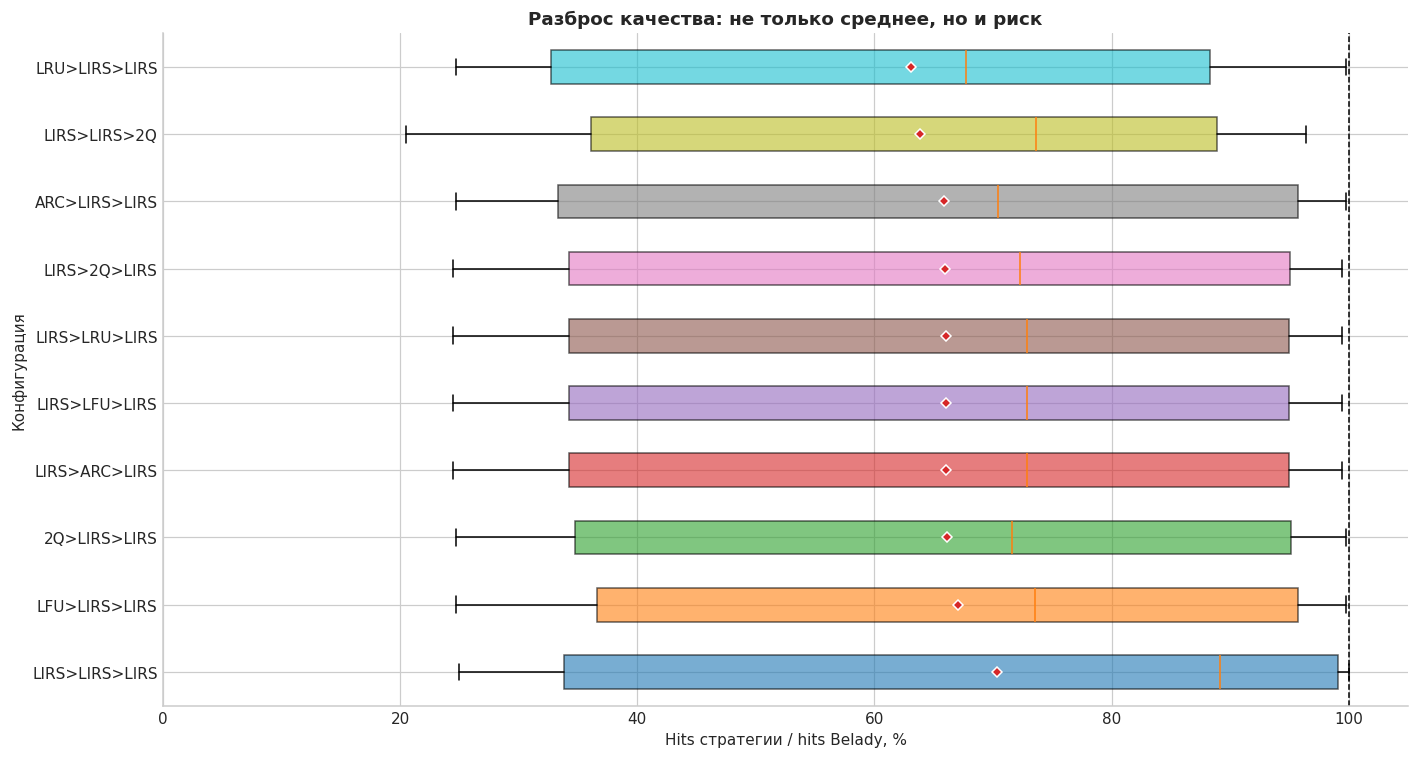

In [8]:
robust_configs = [str(item['policies']) for item in config_summary[:10]]
distributions = [
    [float(row['percent_of_ideal']) for row in by_config[policies]]
    for policies in robust_configs
]

fig, ax = plt.subplots(figsize=(13, 7))
boxes = ax.boxplot(
    distributions, vert=False, patch_artist=True, showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': '#d62728', 'markeredgecolor': 'white', 'markersize': 5},
)
ax.set_yticks(range(1, len(robust_configs) + 1), robust_configs)
for index, box in enumerate(boxes['boxes']):
    box.set_facecolor(COLORS[index % len(COLORS)])
    box.set_alpha(0.60)
ax.axvline(100, color='black', linestyle='--', linewidth=1)
ax.set_xlim(0, 105)
ax.set_xlabel('Hits стратегии / hits Belady, %')
ax.set_ylabel('Конфигурация')
ax.set_title('Разброс качества: не только среднее, но и риск')
fig.tight_layout()
plt.show()

## 6. Чувствительность к размеру кэша

Здесь используется абсолютный hit-rate, а не процент от Belady: график отвечает на вопрос, насколько конкретной политике помогает увеличение resident capacity. Точки агрегируют все паттерны и seeds данного размера.

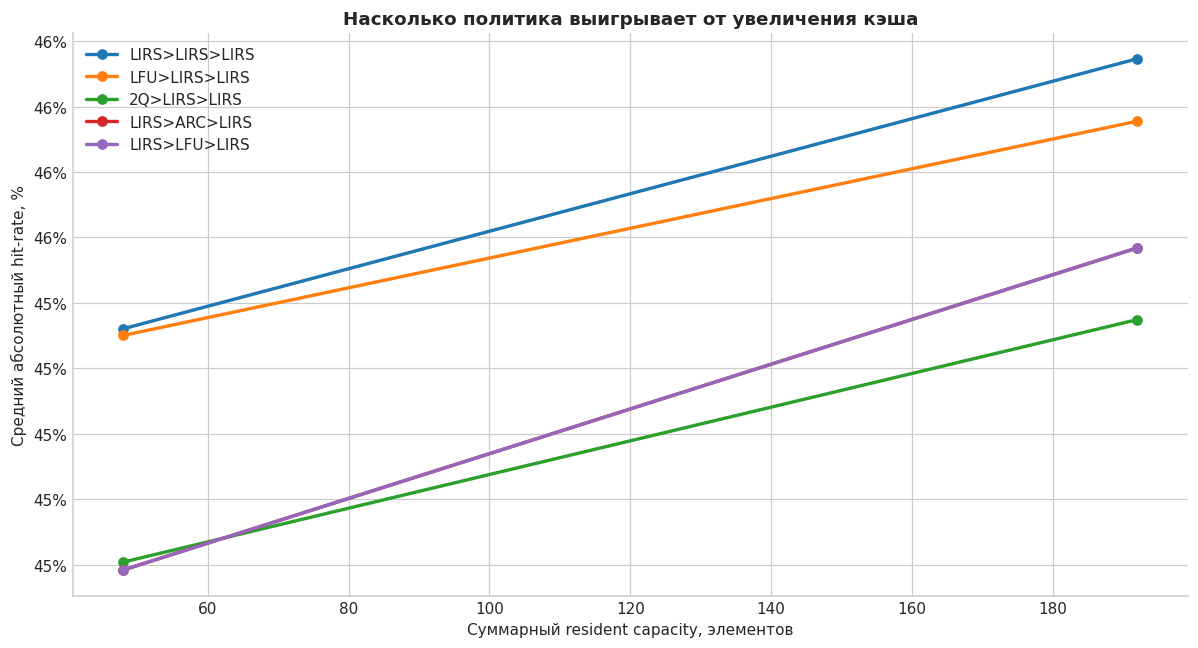

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
for index, policies in enumerate(top5):
    by_capacity: dict[int, list[float]] = defaultdict(list)
    for row in by_config[policies]:
        by_capacity[int(row['total_capacity'])].append(float(row['hit_rate']) * 100)
    capacities = sorted(by_capacity)
    means = [statistics.fmean(by_capacity[capacity]) for capacity in capacities]
    ax.plot(capacities, means, marker='o', linewidth=2.2, color=COLORS[index], label=policies)

ax.set_xlabel('Суммарный resident capacity, элементов')
ax.set_ylabel('Средний абсолютный hit-rate, %')
ax.set_title('Насколько политика выигрывает от увеличения кэша')
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.0f}%'))
fig.tight_layout()
plt.show()

## Как читать результаты

1. Начните с heatmap и выберите строки, сильные на паттернах, похожих на вашу нагрузку.
2. Проверьте boxplot: важен не только mean, но и провалы на отдельных traces.
3. По графику capacity оцените отдачу от дополнительной памяти.
4. Повторите benchmark на обезличенных production traces и с реалистичными размерами уровней.

Не интерпретируйте процент от Belady без абсолютного hit-rate: 95% от небольшого идеального hit-rate может быть практически слабее, чем меньшее относительное значение на workload с большим числом переиспользований.